In [376]:
import gc
print('~'*70)
print('gc ready!')
print('~'*70)
gc.collect()

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
gc ready!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


941

# Tunable_Params [0]

In [377]:
args = {
    'seed'        : 123456,
    'n_positives' : 109921,#'n_positives' : 1099,

    'if_n_estimator'    : 400,
    'if_max_samples'    : 'auto',
    'if_contamination'  : 'auto',

    'cnb_alpha'         : 1 / 47,
    'cnb_force_alpha'   : False,
    'cnb_fit_prior'     : True,
    'cnb_class_prior'   : None,
    'cnb_norm'          : True,
}

In [378]:
print('~'*70)
print('Tunable params:')
print('~'*70)
for k, v in args.items():
    v = ': ' + str(v)
    print(f"{k:<16} {v:<35}")
print('~'*70)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Tunable params:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
seed             : 123456                           
n_positives      : 109921                           
if_n_estimator   : 400                              
if_max_samples   : auto                             
if_contamination : auto                             
cnb_alpha        : 0.02127659574468085              
cnb_force_alpha  : False                            
cnb_fit_prior    : True                             
cnb_class_prior  : None                             
cnb_norm         : True                             
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [379]:
import kagglehub
# KGAT_ef989cc9f567cc710c417faccf4f3a47
K_PATH = kagglehub.competition_download("sem-eval-2026-task-13-subtask-a")
#K_PATH = '/kaggle/input/competitions/sem-eval-2026-task-13-subtask-a'
print('~'*70)
print('data_dir :', K_PATH)
print('~'*70)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
data_dir : C:\Users\Admin\.cache\kagglehub\competitions\sem-eval-2026-task-13-subtask-a
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


# Notebook_Setup [1]

In [380]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('~'*70)
print('pl, pd, np, plt, sns ready!')
print('~'*70)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
pl, pd, np, plt, sns ready!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [381]:
#from huggingface_hun import login
#login(token='')
from huggingface_hub import notebook_login
notebook_login()
print('~'*70)
print('logged in HF!')
print('~'*70)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
logged in HF!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [382]:
# !ls {K_PATH}/Task_A
file_dict = {
    'test_sample' : f'{K_PATH}/Task_A/test_sample.parquet',
    'validation'  : f'{K_PATH}/Task_A/validation.parquet',
    'test'        : f'{K_PATH}/Task_A/test.parquet',
    'train'       : f'{K_PATH}/Task_A/train.parquet',
}

print('~'*70)
for k, v in file_dict.items():
    filename = ': ' + v.replace(K_PATH + '/', '')
    print(f"{k} {filename:>30}")
print('~'*70)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
test_sample   : Task_A/test_sample.parquet
validation    : Task_A/validation.parquet
test          : Task_A/test.parquet
train         : Task_A/train.parquet
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


# Feature_Extract [2]

In [383]:
import re
import math
from collections import Counter

def extract_features(code):
    """Extract language-agnostic handcrafted features from code."""
    lines = code.split('\n')
    n_lines = max(len(lines), 1)
    n_chars = max(len(code), 1)

    # Line-level features
    line_lengths = [len(l) for l in lines]
    avg_line_len = np.mean(line_lengths)
    std_line_len = np.std(line_lengths) if len(line_lengths) > 1 else 0
    max_line_len = max(line_lengths)

    # Indentation features
    indents = [len(l) - len(l.lstrip()) for l in lines if l.strip()]
    avg_indent = np.mean(indents) if indents else 0
    std_indent = np.std(indents) if len(indents) > 1 else 0
    max_indent = max(indents) if indents else 0
    max_nesting_depth = max_indent // 4 if max_indent > 0 else 0

    # Whitespace ratios
    n_spaces = code.count(' ')
    n_tabs = code.count('\t')
    space_ratio = n_spaces / n_chars
    tab_ratio = n_tabs / n_chars

    # Bracket/paren counts (removed n_open_bracket, n_close_bracket)
    n_open_paren = code.count('(')
    n_close_paren = code.count(')')
    n_open_brace = code.count('{')
    n_close_brace = code.count('}')

    # Keyword densities (language-agnostic)
    tokens = re.findall(r'\b\w+\b', code.lower())
    n_tokens = max(len(tokens), 1)

    common_keywords = {'if', 'else', 'for', 'while', 'return', 'def', 'class',
                       'function', 'var', 'let', 'const', 'int', 'string',
                       'import', 'from', 'include', 'using', 'new', 'public',
                       'private', 'static', 'void', 'true', 'false', 'null',
                       'try', 'catch', 'throw', 'switch', 'case', 'break', 'continue'}
    keyword_count = sum(1 for t in tokens if t in common_keywords)
    keyword_ratio = keyword_count / n_tokens

    # Comment indicators
    comment_lines = sum(1 for l in lines if l.strip().startswith(('//', '#', '/*', '*')))
    comment_ratio = comment_lines / n_lines

    # Empty line ratio
    empty_lines = sum(1 for l in lines if not l.strip())
    empty_ratio = empty_lines / n_lines

    # Character entropy
    char_counts = Counter(code)
    total = sum(char_counts.values())
    entropy = -sum((c/total) * math.log2(c/total) for c in char_counts.values() if c > 0)

    # Token uniqueness
    unique_tokens = len(set(tokens))
    token_unique_ratio = unique_tokens / n_tokens

    # Identifier length stats (non-keyword tokens)
    identifiers = [t for t in tokens if t not in common_keywords and not t.isdigit()]
    avg_id_len = np.mean([len(t) for t in identifiers]) if identifiers else 0

    # Semicolons, colons
    n_semicolons = code.count(';') / n_lines
    n_colons = code.count(':') / n_lines

    # Code length features (removed log_code_len)
    code_len = len(code)

    # Single-character identifier ratio
    single_char_ids = sum(1 for t in identifiers if len(t) == 1)
    single_char_ratio = single_char_ids / len(identifiers) if identifiers else 0

    # Spaces around operators (removed operator_density)
    operators = re.findall(r'[+\-*/%=<>!&|^~]', code)
    spaced_operators = len(re.findall(r'\s[+\-*/%=<>!&|^~]\s', code))
    operator_spacing_ratio = spaced_operators / (len(operators) + 1) if operators else 0

    # Average line variability
    line_len_variance = np.var(line_lengths) if len(line_lengths) > 1 else 0

    # Comment verbosity
    comment_line_texts = [l.strip() for l in lines if l.strip().startswith(('//', '#', '/*', '*'))]
    if comment_line_texts:
        comment_word_counts = [len(re.findall(r'\b\w+\b', cl)) for cl in comment_line_texts]
        avg_comment_words = np.mean(comment_word_counts)
        max_comment_words = max(comment_word_counts)
    else:
        avg_comment_words = 0.0
        max_comment_words = 0.0

    # Function definition density
    func_keywords = {'def', 'function', 'void', 'func', 'fn', 'sub', 'proc'}
    func_def_count = sum(1 for t in tokens if t in func_keywords)
    func_def_density = func_def_count / n_lines

    # Long identifier ratio
    long_id_count = sum(1 for t in identifiers if len(t) > 15)
    long_id_ratio = long_id_count / len(identifiers) if identifiers else 0

    # Duplicate line ratio
    non_empty_lines = [l.rstrip() for l in lines if l.strip()]
    n_non_empty = max(len(non_empty_lines), 1)
    duplicate_lines = n_non_empty - len(set(non_empty_lines))
    duplicate_line_ratio = duplicate_lines / n_non_empty

    # Max consecutive empty lines
    max_consec_empty = 0
    cur_consec = 0
    for l in lines:
        if not l.strip():
            cur_consec += 1
            max_consec_empty = max(max_consec_empty, cur_consec)
        else:
            cur_consec = 0

    # Token bigram repetition ratio
    if len(tokens) > 1:
        bigrams = [(tokens[i], tokens[i+1]) for i in range(len(tokens) - 1)]
        bigram_counts = Counter(bigrams)
        repeated_bigrams = sum(1 for c in bigram_counts.values() if c > 1)
        bigram_repetition_ratio = repeated_bigrams / len(bigram_counts)
    else:
        bigram_repetition_ratio = 0.0

    # Import/include density (removed numeric_density)
    import_keywords = {'import', 'from', 'include', 'require', 'using', 'use', 'extern'}
    import_count = sum(1 for t in tokens if t in import_keywords)
    import_density = import_count / n_lines

    # Bracket imbalance
    paren_imbalance = abs(code.count('(') - code.count(')'))
    brace_imbalance = abs(code.count('{') - code.count('}'))
    bracket_imbalance_val = abs(code.count('[') - code.count(']'))
    total_bracket_imbalance = paren_imbalance + brace_imbalance + bracket_imbalance_val

    # Line length percentiles (removed line_len_p75)
    line_len_p25 = float(np.percentile(line_lengths, 25))
    line_len_iqr = float(np.percentile(line_lengths, 75)) - line_len_p25

    # Indentation delta entropy
    all_line_indents = [len(l) - len(l.lstrip()) for l in lines]
    indent_deltas = [abs(all_line_indents[i+1] - all_line_indents[i])
                     for i in range(len(all_line_indents) - 1)]
    if indent_deltas:
        delta_counts = Counter(indent_deltas)
        delta_total = sum(delta_counts.values())
        indent_delta_entropy = -sum((c/delta_total) * math.log2(c/delta_total)
                                     for c in delta_counts.values() if c > 0)
        most_common_delta_ratio = delta_counts.most_common(1)[0][1] / delta_total
    else:
        indent_delta_entropy = 0.0
        most_common_delta_ratio = 0.0

    # Empty line gap consistency
    gaps = []
    gap = 0
    for l in lines:
        if not l.strip():
            gap += 1
        else:
            if gap > 0:
                gaps.append(gap)
            gap = 0
    empty_gap_std = float(np.std(gaps)) if len(gaps) > 1 else 0.0
    empty_gap_mean = float(np.mean(gaps)) if gaps else 0.0

    # Identifier length std dev
    id_len_std = float(np.std([len(t) for t in identifiers])) if len(identifiers) > 1 else 0.0

    # Line length autocorrelation (lag-1)
    if len(line_lengths) > 2:
        ll = np.array(line_lengths, dtype=float)
        x = ll[:-1]
        y = ll[1:]

        if x.std() > 0 and y.std() > 0:
            lag1_autocorr = float(np.corrcoef(x, y)[0, 1])
        else:
            lag1_autocorr = 0.0
    else:
        lag1_autocorr = 0.0

    # Exact-multiple indentation ratio
    exact_indent_lines = sum(1 for i in all_line_indents if i % 4 == 0)
    exact_indent_ratio = exact_indent_lines / n_lines

    # Type annotation / hint density
    type_hint_count = len(re.findall(r':\s*\w+|<\w+>|->\s*\w+', code))
    type_hint_density = type_hint_count / n_lines

    return [
        n_lines,
        avg_line_len,
        std_line_len,
        # max_line_len,
        avg_indent,
        std_indent,
        max_indent,
        space_ratio,
        tab_ratio,
        # n_open_paren,
        # n_close_paren,
        # n_open_brace,
        # n_close_brace,
        keyword_ratio,
        comment_ratio,
        empty_ratio,
        entropy,
        token_unique_ratio,
        avg_id_len,
        # n_semicolons,
        # n_colons,
        code_len,
        n_tokens,
        unique_tokens,
        max_nesting_depth,
        single_char_ratio,
        operator_spacing_ratio,
        line_len_variance,
        avg_comment_words,
        max_comment_words,
        func_def_density,
        long_id_ratio,
        duplicate_line_ratio,
        max_consec_empty,
        bigram_repetition_ratio,
        # import_density,
        # total_bracket_imbalance,
        line_len_p25,
        line_len_iqr,
        indent_delta_entropy,
        most_common_delta_ratio,
        empty_gap_std,
        empty_gap_mean,
        id_len_std,
        lag1_autocorr,
        # exact_indent_ratio,
        # type_hint_density,
    ]

FEATURE_NAMES = [
    'n_lines', 
    'avg_line_len', 
    'std_line_len', 
    # 'max_line_len',
    'avg_indent', 
    'std_indent', 
    'max_indent',
    'space_ratio', 
    'tab_ratio',
    # 'n_open_paren',
    # 'n_close_paren',
    # 'n_open_brace',
    # 'n_close_brace',
    'keyword_ratio',
    'comment_ratio',
    'empty_ratio',
    'entropy',
    'token_unique_ratio',
    'avg_id_len',
    # 'n_semicolons',
    # 'n_colons',
    'code_len',
    'n_tokens',
    'unique_tokens',
    'max_nesting_depth',
    'single_char_ratio',
    'operator_spacing_ratio',
    'line_len_variance',
    'avg_comment_words',
    'max_comment_words',
    'func_def_density',
    'long_id_ratio',
    'duplicate_line_ratio',
    'max_consec_empty',
    'bigram_repetition_ratio',
    # 'import_density',
    # 'total_bracket_imbalance',
    'line_len_p25',
    'line_len_iqr',
    'indent_delta_entropy',
    'most_common_delta_ratio',
    'empty_gap_std',
    'empty_gap_mean',
    'id_len_std',
    'lag1_autocorr',
    # 'exact_indent_ratio',
    # 'type_hint_density',
]

print('~'*70)
print('Handcraft Features defined!')
print('~'*70)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Handcraft Features defined!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [384]:
from tqdm.notebook import tqdm
import os
from concurrent.futures import ProcessPoolExecutor # Import thêm thư viện này
TRAIN_FEATURES_PATH = 'train_features.parquet'
TEST_FEATURES_PATH = 'test_features.parquet'


print('~'*70)
print('Reading train_df and test_df from parquet...')
train_df = pl.read_parquet(file_dict['train'])
test_df = pl.read_parquet(file_dict['test'])
print('~'*70)



if os.path.exists(TRAIN_FEATURES_PATH) and os.path.exists(TEST_FEATURES_PATH):
    print(f'Loading pre-extracted features from {TRAIN_FEATURES_PATH} and {TEST_FEATURES_PATH}...')
    X_hand_train_pd = pd.read_parquet(TRAIN_FEATURES_PATH)
    X_hand_train = X_hand_train_pd.values
    y_train = train_df['label'].to_numpy()

    X_hand_test_pd = pd.read_parquet(TEST_FEATURES_PATH)
    X_hand_test = X_hand_test_pd.values
    print('~'*70)
    print(f'Handcrafted features: train={X_hand_train.shape}')
    print(f'Handcrafted features: test={X_hand_test.shape}')
    print('~'*70)
else:
    print(f'Extracting {len(FEATURE_NAMES)} handcrafted features...')
    print('~'*70)
    X_hand_train = np.array([extract_features(c) for c in tqdm(train_df['code'].to_list())])
    y_train = train_df['label'].to_numpy()
    print(f'Handcrafted features: train={X_hand_train.shape}')
    X_hand_test = np.array([extract_features(c) for c in tqdm(test_df['code'].to_list())])
    print(f'Handcrafted features: test={X_hand_test.shape}')
    print('~'*70)

    # Save the extracted features for future runs
    print(f'Saving extracted features to {TRAIN_FEATURES_PATH} and {TEST_FEATURES_PATH}...')
    pd.DataFrame(X_hand_train, columns=FEATURE_NAMES).to_parquet(TRAIN_FEATURES_PATH, index=False)
    pd.DataFrame(X_hand_test, columns=FEATURE_NAMES).to_parquet(TEST_FEATURES_PATH, index=False)
    print('~'*70)


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Reading train_df and test_df from parquet...
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Loading pre-extracted features from train_features.parquet and test_features.parquet...
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Handcrafted features: train=(500000, 36)
Handcrafted features: test=(500000, 36)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


# Prep_data[3]

In [ ]:
print('Strictly dropping columns with NaN values (No Imputation)...')
# Loại bỏ các cột có chứa giá trị NaN khỏi tập Train
X_hand_train_pd = X_hand_train_pd.dropna(axis=1)

# Đồng bộ tập Test theo các cột còn lại của tập Train
valid_columns = X_hand_train_pd.columns.tolist()
X_hand_test_pd = X_hand_test_pd[valid_columns]

print(f'Remaining valid features: {len(valid_columns)}')

# Định nghĩa Multi-View (Giao cắt với các cột hợp lệ để tránh lỗi Key Error)
base_view_structure = [
    # 'n_lines', 
    'avg_line_len',
    'std_line_len',
    # 'code_len', 
    # 'line_len_variance',
    # 'line_len_p25',
    # 'line_len_iqr',
    # 'lag1_autocorr',
    # 'max_nesting_depth', 
    # 'duplicate_line_ratio',
    # 'max_consec_empty'
]

base_view_indent_style = [
    'avg_indent',
    'std_indent',
    'max_indent',
    # 'space_ratio',
    # 'tab_ratio',
    # 'indent_delta_entropy',
    # 'most_common_delta_ratio',
    'empty_gap_std', 
    'empty_gap_mean',
    # 'operator_spacing_ratio',
    # 'id_len_std',
]

base_view_vocab_syntax = [
    'keyword_ratio',
    'comment_ratio',
    # 'empty_ratio',
    # 'entropy', 
    # 'token_unique_ratio', 
    # 'n_tokens',
    'unique_tokens', 
    'single_char_ratio', 
    # 'avg_comment_words',
    # 'max_comment_words', 
    # 'func_def_density',
    # 'long_id_ratio',
    # 'bigram_repetition_ratio'
]

valid_set = set(valid_columns)
view_structure = [f for f in base_view_structure if f in valid_set]
view_indent_style = [f for f in base_view_indent_style if f in valid_set]
view_vocab_syntax = [f for f in base_view_vocab_syntax if f in valid_set]

views = [
    view_structure, 
    view_indent_style, 
    # view_vocab_syntax
]
view_names = [
    "Structure",
    "Indent & Style",
    # "Vocab & Syntax"
    ]

Strictly dropping columns with NaN values (No Imputation)...
Remaining valid features: 36


# Modeling [4]

In [386]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold

lgbm_params = {
    'objective': 'binary',
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'colsample_bytree': 0.6,
    'subsample': 0.8,
    'reg_alpha': 2.0,
    'reg_lambda': 2.0,
    'min_child_samples': 50,
    'random_state': args['seed'],
    'n_jobs': -1,
    'verbose': -1
}

n_views = len(views)
n_train = len(X_hand_train_pd)
n_test = len(X_hand_test_pd)

oof_meta_train = np.zeros((n_train, n_views))
meta_test = np.zeros((n_test, n_views))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=args['seed'])


In [387]:

print('Training Base Models...')
for view_idx, (view_cols, v_name) in enumerate(zip(views, view_names)):
    if not view_cols:
        continue
        
    print(f"-> View {v_name} ({len(view_cols)} features)")
    
    # Sử dụng .values để tránh warning về Feature Names của LightGBM
    X_v_train = X_hand_train_pd[view_cols].values
    X_v_test = X_hand_test_pd[view_cols].values
    
    # 1. K-Fold OOF
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_v_train, y_train)):
        X_f_train, y_f_train = X_v_train[train_idx], y_train[train_idx]
        X_f_val, _ = X_v_train[val_idx], y_train[val_idx]
        
        base_model = LGBMClassifier(**lgbm_params)
        base_model.fit(X_f_train, y_f_train)
        oof_meta_train[val_idx, view_idx] = base_model.predict_proba(X_f_val)[:, 1]
        
    # 2. Test Prediction
    full_base_model = LGBMClassifier(**lgbm_params)
    full_base_model.fit(X_v_train, y_train)
    meta_test[:, view_idx] = full_base_model.predict_proba(X_v_test)[:, 1]

print('Base models training complete.')
gc.collect()

Training Base Models...
-> View Structure (2 features)


c:\Users\Admin\miniconda3\envs\vector_db\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\vector_db\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\vector_db\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\vector_db\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\vector_db\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier wa

-> View Indent & Style (6 features)


c:\Users\Admin\miniconda3\envs\vector_db\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\vector_db\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\vector_db\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\vector_db\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\vector_db\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier wa

Base models training complete.


116

# Classifier [5]

In [388]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

print('Training Meta-Classifier (QDA) on OOF predictions...')
clf = QuadraticDiscriminantAnalysis()
clf.fit(oof_meta_train, y_train)

Training Meta-Classifier (QDA) on OOF predictions...


,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


In [389]:
print('Calculating probabilities for test set...')
predictions = clf.predict_proba(meta_test)[:, 1]

# Calculate the threshold based on args['n_positives']
if args['n_positives'] <= 0:
    threshold = np.max(predictions) + 1.0 # If 0 positives needed, threshold is higher than any prediction
elif args['n_positives'] >= len(predictions):
    threshold = np.min(predictions) - 1.0 # If all positives needed, threshold is lower than any prediction
else:
    # Sort predictions in descending order to find the (args['n_positives'])-th highest score
    sorted_predictions = np.sort(predictions)[::-1]
    threshold = sorted_predictions[args['n_positives'] - 1]

print(f"Calculated threshold: {threshold:.6f}")
print('~'*70)

# threshold = 0.9999

gc.collect()


Calculating probabilities for test set...
Calculated threshold: 0.999749
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


0

# Predict [6]

In [390]:
print('~'*70)
print('Pending predictions...')

def pr_2_label(scores):
    return [(1 if score > threshold else 0) for score in scores]
    # return [(1 if score > 0.9 else 0) for score in scores]
    
# Apply the threshold and perform random tie-breaking for final labels
final_labels = np.zeros_like(predictions, dtype=int)

# Identify items strictly above the threshold
strictly_above_indices = np.where(predictions > threshold)[0]
final_labels[strictly_above_indices] = 1

num_strictly_above = len(strictly_above_indices)
num_needed_from_ties = args['n_positives'] - num_strictly_above

# if num_needed_from_ties > 0:
#     # Identify items equal to the threshold
#     equal_indices = np.where(predictions == threshold)[0]
#     if len(equal_indices) > 0:
#         rng = np.random.default_rng(args['seed']) # Use seed for reproducibility
#         selected_from_ties_indices = rng.choice(equal_indices, size=num_needed_from_ties, replace=False)
#         final_labels[selected_from_ties_indices] = 1

print(f"Number of predicted positives after thresholding and random tie-breaking: {np.sum(final_labels)}")
print('~'*70)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Pending predictions...
Number of predicted positives after thresholding and random tie-breaking: 109920
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


# Export [7]

In [391]:
print('~'*70)
print('Exporting predictions...')
test_df = test_df.with_columns(pl.Series(name='label', values=final_labels))

test_df.select('ID', 'label').write_csv('submission_lgbm.csv')
print('Done!')
print('~'*70)

gc.collect()

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Exporting predictions...
Done!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


0

In [392]:
import subprocess
filename = 'submission_lgbm.csv'
# Định nghĩa lệnh cần chạy dưới dạng một list các chuỗi
command = [
    "kaggle", 
    "competitions", 
    "submit", 
    "-c", "sem-eval-2026-task-13-subtask-a", 
    "-f", f"{filename}", 
    "-m", filename.replace('.csv', '')
]

try:
    # Chạy lệnh
    result = subprocess.run(command, capture_output=True, text=True, check=True)
    
    # In ra kết quả thành công từ Kaggle
    print("Nộp bài thành công!")
    print(result.stdout)
    
except subprocess.CalledProcessError as e:
    # Bắt lỗi nếu lệnh CLI thất bại (ví dụ: sai tên file, chưa authenticate)
        print("Có lỗi xảy ra khi nộp bài:")
        print(e.stderr)

Nộp bài thành công!
Successfully submitted to SemEval-2026-Task13-Subtask-A


# Metrics [8]

In [393]:
VALIDATION_FEATURES_PATH = 'validation_features.parquet'

print('~'*70)
print('Validating on validation_df...')

validation_df = pl.read_parquet(file_dict['validation'])

if os.path.exists(VALIDATION_FEATURES_PATH):
    print(f'Loading pre-extracted validation features from {VALIDATION_FEATURES_PATH}...')
    X_hand_validation_pd = pd.read_parquet(VALIDATION_FEATURES_PATH)
    X_hand_validation = X_hand_validation_pd.values
else:
    print(f'Extracting handcrafted features for validation set...')
    X_hand_validation = np.array([extract_features(c) for c in tqdm(validation_df['code'].to_list())])
    print(f'Saving extracted validation features to {VALIDATION_FEATURES_PATH}...')
    pd.DataFrame(X_hand_validation, columns=FEATURE_NAMES).to_parquet(VALIDATION_FEATURES_PATH, index=False)

y_validation = validation_df['label'].to_numpy()

# Get probabilities for AUC calculation
y_proba = get_proba(X_hand_validation, clf)

# Convert probabilities to hard labels for other metrics
y_prediction = np.array(pr_2_label(y_proba))

print('~'*70)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Calculate metrics
accuracy = accuracy_score(y_validation, y_prediction)
precision = precision_score(y_validation, y_prediction, average='macro')
recall = recall_score(y_validation, y_prediction, average='macro')
f1 = f1_score(y_validation, y_prediction, average='macro')
auc = roc_auc_score(y_validation, y_proba)

# Create a Polars DataFrame for the metrics
metrics_df = pl.DataFrame({
    'Metric': ['acc', 'precision (Macro)', 'recall (Macro)', 'f1 (Macro)', 'auc'],
    'Value': [accuracy, precision, recall, f1, auc]
})

print('\nValidation Metrics:')
display(metrics_df)
print('~'*70)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Validating on validation_df...
Loading pre-extracted validation features from validation_features.parquet...


NameError: name 'get_proba' is not defined

# Visualizing [9]

  0%|          | 0/1000 [00:00<?, ?it/s]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
X_hand_test_sample shape: (1000, 39) y_test shape: (1000,)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


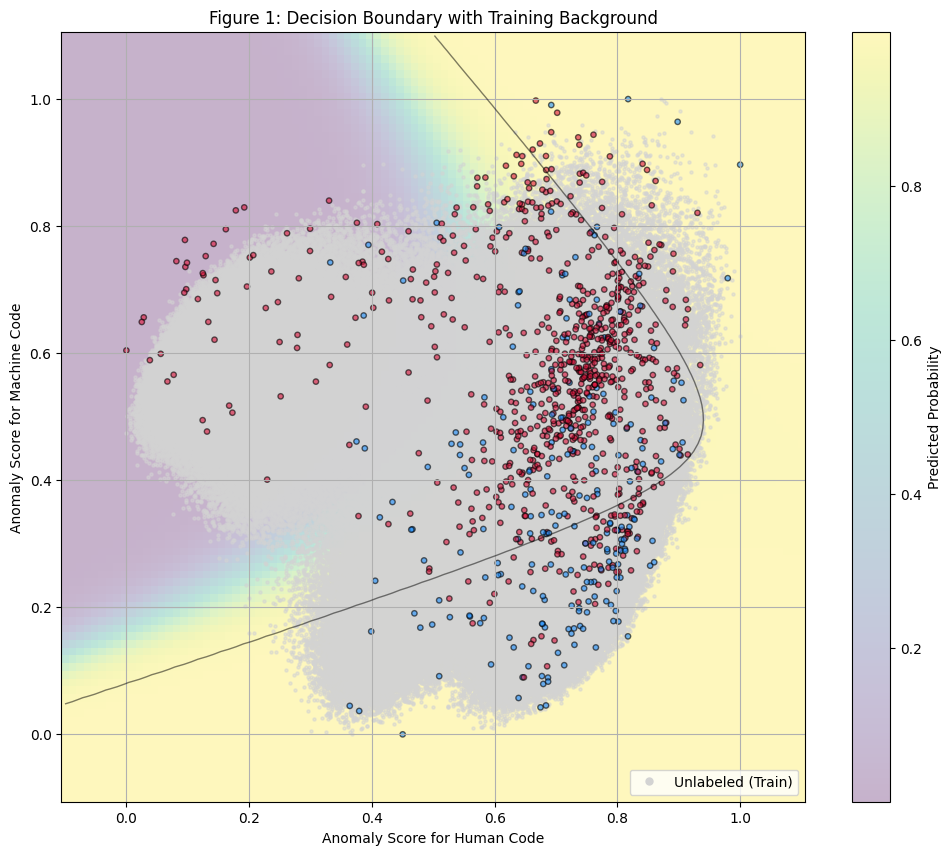

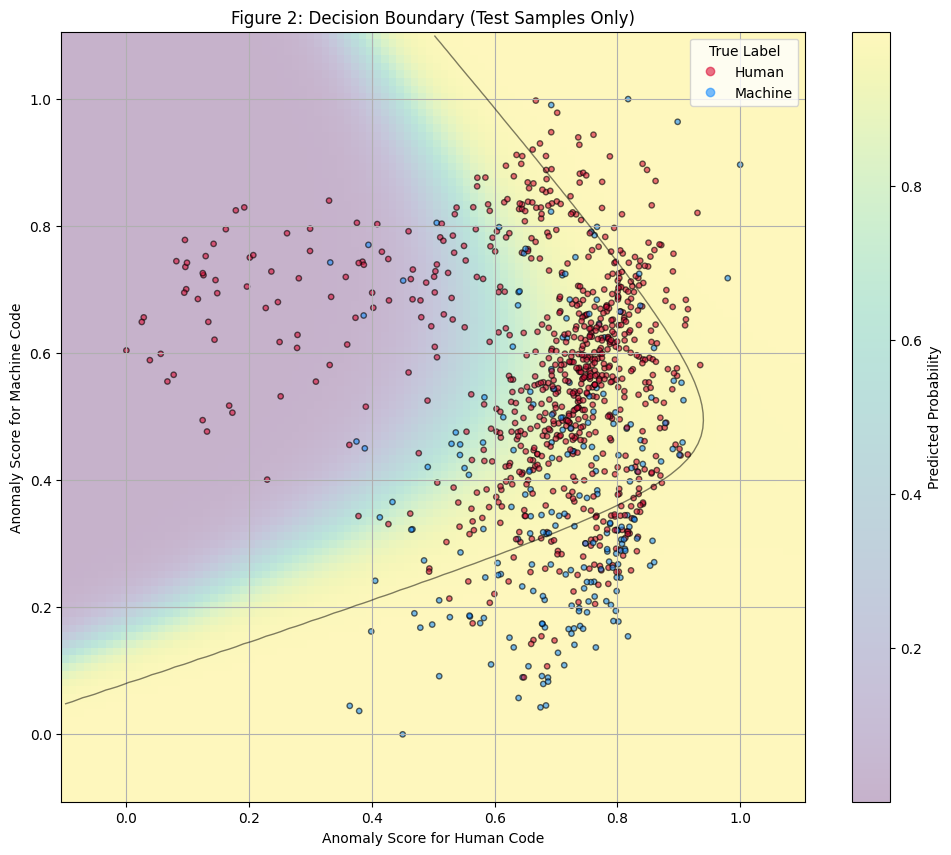

In [ ]:
test_sample_df = pl.read_parquet(file_dict['test_sample'])
X_hand_test_sample = np.array([extract_features(c) for c in tqdm(test_sample_df['code'].to_list())])
y_test = test_sample_df['label'].to_numpy()

print('~'*70)
print('X_hand_test_sample shape:', X_hand_test_sample.shape, 'y_test shape:', y_test.shape)
print('~'*70)

score_human_machine_test = bi_anomoly(X_hand_test_sample, quant, if_human, if_machine)
X_2d_test_example = np.array(list(score_human_machine_test))

from matplotlib.colors import ListedColormap

custom_colors = ['crimson', 'dodgerblue']
custom_cmap = ListedColormap(custom_colors)

# Define plot boundaries
x_min, x_max = X_2d_test_example[:, 0].min() - 0.1, X_2d_test_example[:, 0].max() + 0.1
y_min, y_max = X_2d_test_example[:, 1].min() - 0.1, X_2d_test_example[:, 1].max() + 0.1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# --- Figure 1: With Background ---
plt.figure(figsize=(12, 10))
plt.pcolormesh(xx, yy, Z, alpha=0.3, cmap='viridis', shading='auto')
plt.colorbar(label='Predicted Probability')
plt.contour(xx, yy, Z, levels=[threshold], colors='black', linestyles='solid', linewidths=1, alpha=.5)

plt.scatter(X_2d_train[:, 0], X_2d_train[:, 1], color='lightgray', alpha=0.5, s=5, label='Unlabeled (Train)')
scatter1 = plt.scatter(X_2d_test_example[:, 0], X_2d_test_example[:, 1], c=y_test, cmap=custom_cmap, alpha=0.6, s=15, edgecolors='k')

plt.xlabel('Anomaly Score for Human Code')
plt.ylabel('Anomaly Score for Machine Code')
plt.title('Figure 1: Decision Boundary with Training Background')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='lightgray', linestyle='', markersize=5)], labels=['Unlabeled (Train)'], loc='lower right')
plt.grid(True)
plt.show()

# --- Figure 2: Without Background ---
plt.figure(figsize=(12, 10))
plt.pcolormesh(xx, yy, Z, alpha=0.3, cmap='viridis', shading='auto')
plt.colorbar(label='Predicted Probability')
plt.contour(xx, yy, Z, levels=[threshold], colors='black', linestyles='solid', linewidths=1, alpha=.5)

scatter2 = plt.scatter(X_2d_test_example[:, 0], X_2d_test_example[:, 1], c=y_test, cmap=custom_cmap, alpha=0.6, s=15, edgecolors='k')

plt.xlabel('Anomaly Score for Human Code')
plt.ylabel('Anomaly Score for Machine Code')
plt.title('Figure 2: Decision Boundary (Test Samples Only)')
legend_labels = ['Human', 'Machine']
plt.legend(handles=scatter2.legend_elements()[0], labels=legend_labels, title='True Label', loc='upper right')
plt.grid(True)
plt.show()